## Black-Scholes Model & Implied Volatility Surface

#### Manan Verma

#### 28 June, 2026

In [ ]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from scipy.stats import norm
from datetime import date
import plotly.graph_objects as go

***
#### Options Basics

By definition, an ***option*** (an option's contract) gives the buyer the right, but not the obligation, to buy or sell an asset (also called the "underlying") at a *predetermined* price (also called the "strike price") within a specific timeframe (the termination of which is called the option's "expiry" date). The buyer will pay the option's seller a fee (called the "premium") for each share in this contract. One equity options contract controls *100* shares of the underlying.    

For *American* options, the buyer can exercise the option (buy or sell the underlying) at any time before the expiry date, while for *European* options, the buyer must exercise the option on the expiry date.  

A ***Call*** option gives the buyer the right to *buy* the underlying at a predtermined price, thus the buyer can accumulate profit if the price of the underlying rises above the strike price + premium price.  
A ***put*** option gives the buyer the right to *sell* the underlying at a predetermined price, thus the buyer can accumulate profit if the underlying falls below the strike price + premium price. 

If, by the end of the option's timeframe, the underlying has not risen or fallen by enough, then the buyer need not exercise the contract; rather they will simply pay the seller the premium. Therefore, for a call option, the buyer's max upside is theoretically *infinite* while the max downside (risk) is *the price of the premium* (multiplied by 100 for each contract); and for the seller the max upside is the *premium* while the max downside is theoretically *infinite*.  
Meanwhile, for a put option, the buyer's max upside is *the current price of the underlying* (because its price could theoretically only drop as low as zero) while the max downside is *the price of the premium*; and for the seller the max upside is the *premium* while the max downside is theoretically *the current price of the underlying*.

***
#### Options Greeks

The ***Greeks*** of options are measures of how much an option's price changes relative to several underlying variables. They are categorized into first-order, second-order, and third-order, based on the order of their derivative from the option's price. Below are some examples of commonly used greeks, though several other exist (*$V$ will be used for the option's price & $S$ will be used for the underlying's price*):

**<u>First Order</u>**:  
- <u>Delta</u> ($\Delta$)
    * Measures the sensitivity of the option's price to changes of the price of the underlying.
$$\Delta = \frac{\partial V}{\partial S}$$
- <u>Vega</u> ($\nu$)
    * Measures the sensitivity of the option's price to the volatility (or implied volatility) of the underlying.
$$\nu = \frac{\partial V}{\partial \sigma}$$
- <u>Theta</u> ($\Theta$) 
    * Measures the sensitivity of the option's price to time.
$$\Theta = \frac{\partial V}{\partial t}$$
- <u>Rho</u> ($\rho$)
    * Measures the sensitivity of the option's price to interest rates.
$$\rho = \frac{\partial V}{\partial r}$$

**<u>Second Order</u>**:
- <u>Gamma</u> ($\Gamma$)
    * Measures the sensitivity of the option's Delta to changes of the price of the underlying.
$$\Gamma = \frac{\partial \Delta}{\partial S} = \frac{\partial^2 V}{\partial S^2}$$
- <u>Vomma</u> ($Vomma$)
    * Measures the sensitivity of the option's Vega to volatility (or implied volatility).
$$Vomma = \frac{\partial \nu}{\partial \sigma} = \frac{\partial^2 V}{\partial \sigma^2}$$
- <u>Vanna</u> ($Vanna$)
    * Measures the sensitivity of the option's Delta to volatility (or implied volitility).
$$Vanna = \frac{\partial \Delta}{\partial \sigma} = \frac{\partial^2 V}{\partial S \partial \sigma}$$
- <u>Charm</u> ($Charm$)
    * Measures the sensitivity of the option's Delta to time.
$$Charm = \frac{\partial \Delta}{\partial t} = \frac{\partial^2 V}{\partial S \partial t}$$

**<u>Third Order</u>**:
- <u>Speed</u> ($Speed$)
    * Measures the of the option's Gamma to changes of the price of the underlying.
$$Speed = \frac{\partial \Gamma}{\partial S} = \frac{\partial^3 V}{\partial S^3}$$
- <u>Color</u> ($Color$)
    * Measures the sensitivity of the option's Gamma to time.
$$Color = \frac{\partial \Gamma}{\partial t} = \frac{\partial^3 V}{\partial S^2 \partial t}$$

***  
#### Black-Scholes Modeling

The ***Black-Scholes Model*** is one of the most foundational models used in finance to calculate the theoretical fair price of European options contracts.  
The model relies on several assumtions, many of which do not translate to real-world markets and thus limits the practical applicability of the model. Nonetheless, the model remains fundamental to financial markets. Some of these assumtions include:
- **European Options**: the model only works for European Options.
- **Underlying Distribution**: the underlying stock, etc. prices must follow a *random walk* and have a log-normal distribution.
- **Constant Volatility and Rates**: the volatility of the underlying must remain constant and be known, likewise interest rates must also remain constant.
- **Frictionless Markets**: there are no transaction costs or taxes.

The foundation of the model is **Brownian Motion**, or the **Wiener Process**, which is a *continuous-time, stochastic* process with *independent*, *Gaussian* increments. That means that every step's change follows a Normal Distribution, and the change in every step is independent from the previous step (this is known as the *Martingale Property*, where the best prediction of a future value is the current value). Mathematically, Brownian Motions is denoted as $W_t$, with the following properties:
$$W_0 = 0$$
$$W_t - W_s \sim \mathcal{N}(0, t - s), ~ \forall t > s$$
$$\Rightarrow dW_t \sim \mathcal{N}(0, dt)$$
Below, pure Brownian Motion will be simulated:


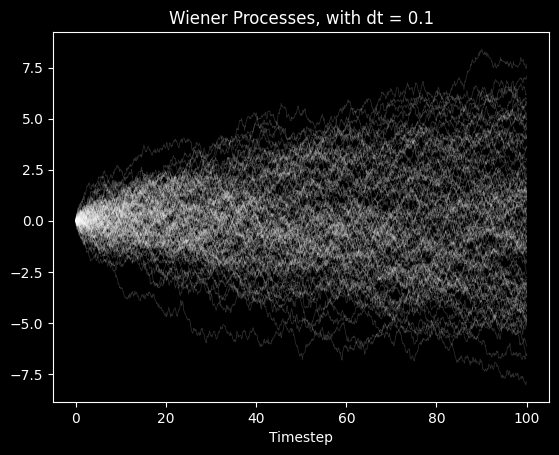

In [ ]:
#Visualize pure Brownian Motion

def brownian_motion():
    """Creates a Brownian Motion path.
       Takes in no input, outputs a list of 1000 points which follow the Wiener Process with dt = 0.1"""
    path = np.zeros(1000)
    dt = 0.1
    
    for i in range (1, 1000):
        path[i] = path[i - 1] + np.random.normal(0, dt)
    
    return path

x = np.linspace(0, 100, 1000)
plt.style.use('dark_background')
for i in range(100):
    plt.plot(x, brownian_motion(), color = 'white', alpha = 0.2, linewidth = 0.5)
plt.title("Wiener Processes, with dt = 0.1")
plt.xlabel('Timestep')

plt.show()

This process is the first major assumption that the model takes on: **all randomness in the price is driven by Brownian Motion**. However, Brownian Motion can take on negaive values, which a stock cannot. Thus, the stock price's returns will be modeled using a *log-normal distribution*, where the natural logarithm of the stock price follows a Normal Distribution. Furthermore, a deterministic *drift* element, $\mu$ is added alongside the random walk, $dW_t$. This model, known as **Geometric Browninan Motion**, is the underlying interpretation of stock movements that the Black-Scholes Model uses, and is shown mathematically as:
$$dS_t = \mu S_tdt + \sigma S_tdW_t$$
where $S_t$ is the stock price at time $t$,  
$\mu$ is the drift, which represents the expected returns of the stock over time,  
$\sigma$ is the volatility of the stock,  
and $dW_t$ is the random, Brownian term.  
The reason this is referred to as *Geometric* Brownian Motion is because the volatility and drift are scaled by the current stock price, $S_t$, making it geometric rather than arithmetic.

An exact, closed-form solution of GBM will be derived; however an approximation called the Euler-Maruyama Discretization exists:
$$S_{t + \Delta t} = S_t + \mu S_t\Delta t + \sigma S_t \sqrt{\Delta t}Z ~~ ,Z \sim \mathcal{N}(0, 1)$$
*note that this approximation could produce negative values, however the closed-form guarantees strictly positive values*

To obtain a closed-form solution of GBM, **Itô's Lemma** will be used, which is the stochastic equivalent of the chain rule from ordinary calculus.  
First, take note of some important properties:  
$$dt^2 = 0$$
because as $dt \rightarrow 0$, the square approaches zero significantly faster.
$$dtdW_t = 0$$
This is because $dW_t$ has a variance of $dt$, and therefore a standard deviation of $\sqrt{dt}$. Thus, it can be shown that $dW_t = \epsilon \sqrt{dt}$, where $\epsilon \sim \mathcal{N}(0, 1)$, meaning that $dW_t$ is of order $\sqrt{dt}$. Hence, $dtdW_t$ has magnitude $dt^{\frac{3}{2}}$, and will approach zero faster than $dt$.
$$dW_t^2 = dt$$
again, because $dW_t$ is of order $\sqrt{dt}$.

Also recall the *Taylor Expansion* of a function, $f$ about the point $x$ and evaluated at $x + dx$, is given by:  
$$f(x + dx) = f(x) + f'(x)dx + \frac{1}{2}f''(x)dx^2 + \cdots = \sum_{i = 0}^{\infty} \frac{f^{(i)}(x)dx^i}{i!}$$
where $f^{(i)}$ is the $i$ th derivative of $f$.

Now, consider a function $f(t, W_t)$, which is a function of both *time* and *Brownian Motion*. Applying the the Taylor Expansion for a multivariable function about the point $(t, W_t)$ and evaluating at $(t + dt, W_{t + dt})$ gives:  
$$f(t + dt, W_{t + dt}) = f(t, W_t) + \frac{\partial f}{\partial t}dt + \frac{\partial f}{\partial W_t}dW_t + \frac{1}{2}\frac{\partial^2 f}{\partial t^2}dt^2 + \frac{\partial^2 f}{\partial t \partial W_t}dtdW_t + \frac{1}{2}\frac{\partial^2 f}{\partial W_t^2}dW_t^2$$
Then, taking $df = f(t + dt, W_{t + dt}) - f(t, W_t)$, dropping all terms that are of a higher order than $dt$, and taking $dW_t^2 = dt$, *Itô's Lemma* is obtained:
$$\implies df = \frac{\partial f}{\partial t}dt + \frac{\partial f}{\partial W_t}dW_t + \frac{1}{2}\frac{\partial^2 f}{\partial W_t^2}dt$$

Now, to solve GBM, start with:
$$\frac{dS_t}{S_t} = \mu dt + \sigma dW_t$$

Ordinarily, $\frac{dS_t}{S_t} = d(\textrm{ln}S_t)$; however because $S_t$ is a stochastic function, Itô's Lemma will have to be applied to $f = \text{ln}S_t$:
$$d(\textrm{ln}S_t) = \frac{\partial \textrm{ln}S_t}{\partial t}dt + \frac{\partial \textrm{ln}S_t}{\partial S_t}dS_t + \frac{1}{2}\frac{\partial^2 \textrm{ln}S_t}{\partial S_t^2}dS_t^2$$
$$= 0 + \frac{1}{S_t}dS_t + \frac{1}{2}\left(-\frac{1}{S_t^2}\right)dS_t^2$$
From the original GBM equation:
$$dS_t^2 = (\mu S_tdt + \sigma S_tdW_t)^2 = \mu^2 S_t^2dt^2 + \sigma^2 S_t^2dW_t^2 + 2\mu \sigma S_t^2 dt dW_t$$
and dropping all higher-order terms:
$$dS_t^2 = \sigma^2 S_t^2dt$$
Then, substituting both $dS_t$ and $dS_t^2$:
$$d(\textrm{ln}S_t) = \frac{1}{S_t}\left(\mu S_tdt + \sigma S_tdW_t\right) + \frac{1}{2}\left(-\frac{1}{S_t^2}\right)\left(\sigma^2 S_t^2dt\right)$$
$$= \mu dt - \frac{1}{2}\sigma^2 dt + \sigma dW_t$$
And integrating:
$$\int_t^{t + \Delta t} d(\textrm{ln}S_t) = \int_t^{t + \Delta t} \left(\mu - \frac{1}{2}\sigma^2\right) dt + \int_t^{t + \Delta t} \sigma dW_t$$
$$\textrm{ln}S_{t + \Delta t} - \textrm{ln}S_t = \left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma W_t$$
Finally, the closed form of GBM is obtained:
$$S_{t + \Delta t} = S_te^{\left[\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma W_t\right]}$$
$$with ~~ W_t = \sqrt{\Delta t}Z~~, Z \sim \mathcal{N}(0, 1)$$

*Notice that, since $W_t$ is normally distributed, $S_{t + \Delta t}$ is log-normally distributed.*

Below, Geometric Brownian Motion will be simulated:

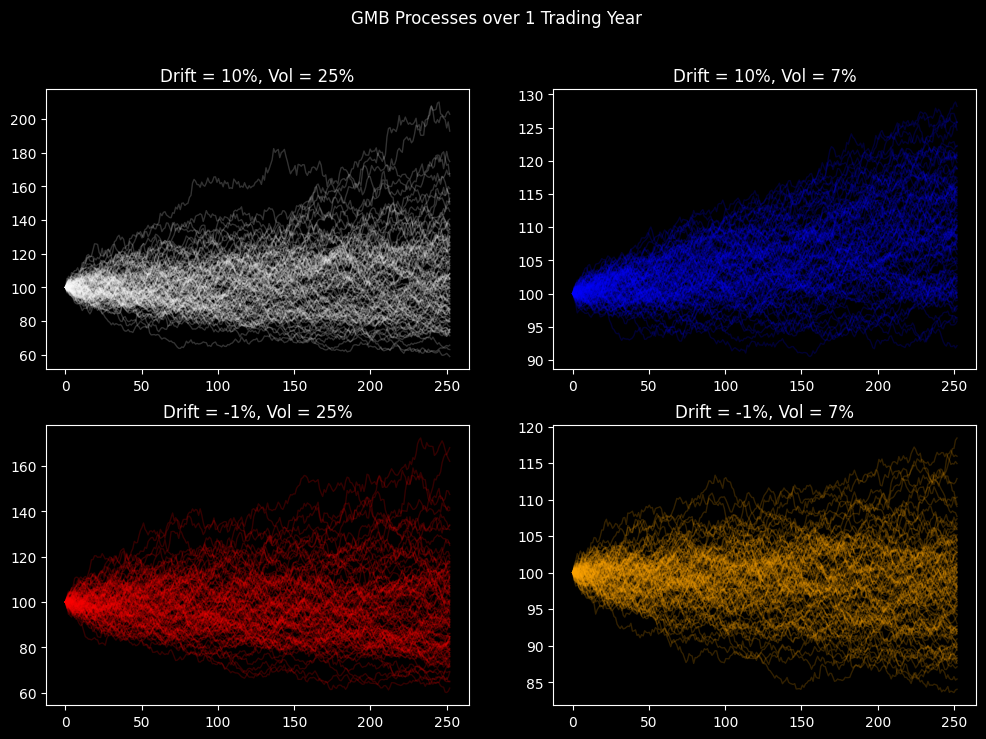

In [ ]:
#Visualize Geometric Brownian Motion

def gbm(mu, sigma):
    """Creates a Geometric Brownian Motion path.
       Takes in the drift (mu) and volatility (sigma) terms as inputs,
       outputs a list of 252 points (1 year) which follow the GBM Process with dt = 1 day, and starting price of $100"""
    path = np.zeros(252)
    dt = 1/252
    path[0] = 100
    
    for i in range (1, 252):
        z = np.random.normal(0, 1)
        path[i] = path[i - 1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z) 
    
    return path

x = np.linspace(0, 252, 252)
plt.style.use('dark_background')
fig, ax = plt.subplots(2, 2, figsize = (12, 8))
for i in range (100):
    ax[0, 0].plot(x, gbm(0.10, 0.25), color = 'white', alpha = 0.2, linewidth = 1)
ax[0, 0].set_title('Drift = 10%, Vol = 25%')
for i in range (100):
    ax[1, 0].plot(x, gbm(-0.01, 0.20), color = 'red', alpha = 0.2, linewidth = 1)
ax[1, 0].set_title('Drift = -1%, Vol = 25%')
for i in range (100):
    ax[0, 1].plot(x, gbm(0.10, 0.07), color = 'blue', alpha = 0.2, linewidth = 1)
ax[0, 1].set_title('Drift = 10%, Vol = 7%')
for i in range (100):
    ax[1, 1].plot(x, gbm(-0.01, 0.07), color = 'orange', alpha = 0.2, linewidth = 1)
ax[1, 1].set_title('Drift = -1%, Vol = 7%')
plt.suptitle("GMB Processes over 1 Trading Year")

plt.show()

It follows that Geometric Brownian Motion models stock returns with some major (oftentimes unrealistic) assumptions:  
- Stock returns are lognormally distrubuted.
    * This implies tail events are much rarer than what happens in reality.
- Volatility, $\sigma$, remains constant throughout and is known.
    * A stock's true volatility (especially future volatility) is rarely ever known.
    * A stock's volatility is always changing. Some models, like the *Heston Model*, aim to address this.
- Stock prices are continuous and smooth throughout.
    * Prices can experience extreme jumps or gaps. There are *Jump Diffusion Models* that aim to address this.

Now, to derive the Black-Scholes options pricing model from GBM, first introduce an option. Let the function $V$ denote the value of a derivative (like a call or put option, etc), which depends on both the price of the underlying stock, $S$, and time, $t$:
$$V(S, t)$$
Since $S$ is a stochastic variable, Itô's Lemma can be applied to $V$:
$$dV = \frac{\partial V}{\partial t}dt + \frac{\partial V}{\partial S}dS + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}dS^2$$
Next, using
$$dS = \mu Sdt + \sigma S dW$$
and
$$dS^2 = \sigma^2 S^2 dt$$
Thus:
$$dV = \frac{\partial V}{\partial t}dt + \frac{\partial V}{\partial S}\left( \mu Sdt + \sigma S dW\right) + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}\sigma^2 S^2 dt$$
$$\implies dV = \left(\frac{\partial V}{\partial t} + \frac{\partial V}{\partial S}\mu S + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}\sigma^2 S^2\right)dt + \frac{\partial V}{\partial S}\sigma S dW$$

Now, a *risk free* portfolio will be created using **Delta-Hedging**. This is another assumption the Black-Scholes Model makes: the trader can continuously (i.e., infinitely) adjust the asset holdings- with no transaction costs- via delta-hedging in order to completely hedge away all risk.  
Delta-hedging essentially aims to create a portfolio with a net-zero delta (remember, delta, one of the option greeks, is $\Delta = \frac{\partial V}{\partial S}$). To do this for a call option, the trader would short an amount of stock proportional to the current delta (for example, for a +40 delta portfolio (where $\Delta$ = 0.4), 40 shares of stock are shorted). For a put option, the trader would buy a *delta* amount of stock. The amount of stock either bought or shorted must be constantly changed as the delta changes over the lifetime of the option.

Now, construct the risk free portfolio, which has value $\Pi$:
$$\Pi = V - \Delta S$$
assume that hedging can be done continuously:
$$d\Pi = dV - \Delta dS$$
and substitute (using $\Delta = \frac{\partial V}{\partial S}$):
$$d\Pi = \left(\frac{\partial V}{\partial t} + \frac{\partial V}{\partial S}\mu S + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}\sigma^2 S^2\right)dt + \frac{\partial V}{\partial S}\sigma S dW - \frac{\partial V}{\partial S} \left(\mu Sdt + \sigma S dW \right)$$
$$\implies d\Pi = \left(\frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}\sigma^2 S^2\right)dt$$
This portfolio is now *riskless* because there is no dependence on $dW$, the randomness, and price changes are now completely deterministic.  
Since this portfolio is risk-free, it must earn the risk-free rate, $r$. (The Black-Scholes Model also assumes that no arbitrage opportunities exists, where the constructed portfolio earns higher than the risk-free rate). Therefore the value of the portfolio is continuously compounded:
$$d\Pi = r\Pi dt$$
and using
$$\Pi = V - \frac{\partial V}{\partial S} S$$
the following is obtained:
$$\left(\frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}\sigma^2 S^2\right)dt = r\left(V - \frac{\partial V}{\partial S}S\right)dt$$
and rearranging gives the ***final Black-Scholes PDE***:
$$\boxed{\frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}\sigma^2 S^2 + rS\frac{\partial V}{\partial S} - rV = 0}$$

*Something interesting to take note of is that the price of the option, $V$, doesn't even depend on the expected returns of the stock, $\mu$. This can be attributed to the fact that the portfolio is risk-free after delta-hedging, and expected returns can be thought of as being compensation for taking on additional risk.*

In order to solve the PDE and arrive at a closed-form solution for $V$, the PDE must be transformed into the **Heat Equation** PDE. This is done as follows:  
First, the terminal condition of $V$ given the stock price $S$ and strike price $K$ is the option's final value (the expiry time is denoted as $T$, and the current time is $t$), which is:  
$$V_T = max\{S_T - K, 0\}$$
Also, the time direction is reversed such that:
$$\tau = T - t$$
*In the reversed-time-direction universe, the stock and option prices will be written as $\tilde{S}$, and $\tilde{V}$, such that the stock price at expiry is $\tilde{S}_0$, the price of the stock now is $\tilde{S}_{\tau}$, etc.*  
Then, since the stock price follows Geometric Brownian Motion, it can be written using the closed form of GBM, as derived above:  
$$\tilde{S}_0 = e^{[\textrm{ln}\tilde{S}_{\tau} + \left(r - \frac{1}{2}\sigma^2 \right)\tau ]}$$
where the stochastic term has been omitted because it is taken care of by the PDE, and the risk-free rate $r$ is used for the expected returns.  
Then, define:
$$x = \textrm{ln}\tilde{S}_{\tau} + \left(r - \frac{1}{2}\sigma^2 \right)\tau\$$
And, finally, transform the current price of the option to its forward value:
$$F_{\tau} = \tilde{V}_{\tau}e^{r\tau}$$
The first 2 transformations give:  
$$\frac{\partial V}{\partial S} = \frac{\partial \tilde{V}}{\partial \tilde{S}}$$
$$\frac{\partial V}{\partial t} = -\frac{\partial \tilde{V}}{\partial \tau}$$
$$\frac{\partial \tilde{V}}{\partial \tilde{S}} = \frac{1}{\tilde{S}}\frac{\partial \tilde{V}}{\partial x}$$
$$\frac{\partial^2 \tilde{V}}{\partial \tilde{S}^2} = \frac{1}{\tilde{S}^2} \left(-\frac{\partial \tilde{V}}{\partial x} + \frac{\partial^2 \tilde{V}}{\partial x^2} \right)$$
$$\frac{\partial \tilde{V}}{\partial \tau} = \frac{\partial \tilde{V}}{\partial \tau} + \frac{\partial \tilde{V}}{\partial x}\left(r - \frac{1}{2}\sigma^2 \right)$$
With these transformations, the PDE becomes a forward PDE (whereas the original one was backward) with constant coefficients (i.e., the $S$ and $S^2$ are no longer). *Backward differential equations determine earlier states given final or terminal states, while forward differential equations determine future states using initial conditions.*  
$$-\frac{\partial \tilde{V}}{\partial \tau} + \frac{1}{2}\sigma^2\frac{\partial^2\tilde{V}}{\partial x^2} - r\tilde{V} = 0$$
Subsequently, the third transformation gives:
$$\frac{\partial^2 \tilde{V}}{\partial x^2} = e^{-r\tau}\frac{\partial^2 F}{\partial x^2}$$
$$\frac{\partial \tilde{V}}{\partial \tau} = e^{-r\tau}\frac{\partial F}{\partial \tau} - rFe^{-r\tau}$$
Then, substituting these gives the *heat equation* (in one dimension):
$$\frac{\partial F}{\partial \tau} = \frac{1}{2}\sigma^2\frac{\partial^2 F}{\partial x^2}$$

There are several methods to solve the heat equation, and doing so results in the ***final, closed-form solution*** for the Black-Scholes Model for both Call ($C$) and Put ($P$) options:
$$\boxed{C = S\Phi(d_1) - Ke^{-rT}\Phi(d_2)}$$
$$\boxed{P = -S\Phi(-d_1) + Ke^{-rT}\Phi(-d_2)}$$
where
$$d_1 = \frac{\textrm{ln}\left(\frac{S}{K}\right) + T\left(r + \frac{1}{2}\sigma^2\right)}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$
and $\Phi (z)$ is the cumulative distribution function of the standard normal distribution:
$$\Phi (z) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{z}e^{-\frac{1}{2}y^2}dy$$

***
Because there is a closed form solution, it is very easy to create a function that can calculate the theoretical fair price of an option given
- The current stock price, $S$ 
- The strike price, $K$ 
- The risk free rate, $r$
- The time to expiry, $T$
- The volatility of the underlying, $\sigma$

In [ ]:
#Calculate option price within Black-Scholes framework

def bs_price(stock_price, strike_price, rfr, time, vol, option_type):
    """Calculates the theoretical fair price of a European options contract"""
    if (vol <= 0):
        raise ValueError("Volatility must be positive")
    
    d1 = (np.log(stock_price / strike_price) + time * (rfr + 0.5 * vol**2)) / (vol * np.sqrt(time))
    d2 = d1 - (vol * np.sqrt(time))

    if (option_type.lower() == 'call'):
        if (time <= 0):
            return max(stock_price - strike_price, 0)
        return (stock_price * norm.cdf(d1)) - (strike_price * np.exp(-1 * rfr * time) * norm.cdf(d2))
    
    elif (option_type.lower() == 'put'):
        if (time <= 0):
            return max(strike_price - stock_price, 0)
        return (-1 * stock_price * norm.cdf(-1 * d1)) + (strike_price * np.exp(-1 * rfr * time) * norm.cdf(-1 * d2)) 
      
    else:
        raise ValueError("option_type must be either 'call' or 'put'")
    

S = 540.20
K = 600
r = 0.0395
T = 147/365
sigma = 0.43
type = 'Call'

option_price = bs_price(S, K, r, T, sigma, type)

print(f"A {type.lower()} option for a ${S:.2f} stock\nwith a ${K:.2f} strike price\nthat expires in {T:.3f} year(s)\nwith {sigma * 100:.1f}% annualized volatility\nwith a risk-free-rate of {r * 100:.3f}% will have a theoretical best price of: \n${option_price:.2f}")

A call option for a $540.20 stock
with a $600.00 strike price
that expires in 0.403 year(s)
with 43.0% annualized volatility
with a risk-free-rate of 3.950% will have a theoretical best price of: 
$39.41


With this, the option's *Greeks* can also be calculated. Notice that the Black-Scholes PDE can be written in terms of several Greeks:
$$\frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}\sigma^2 S^2 + rS\frac{\partial V}{\partial S} - rV = 0 ~ \Longleftrightarrow ~ \Theta + \frac{1}{2}\sigma^2S^2\Gamma + rS\Delta = rV$$
To find closed-form solutions for the Greeks, the Black-Scholes equation is simply differentiated. The five primary Greeks can be calculated as:
$$\Delta_{call} = \Phi(d_1) \qquad \Delta_{put} = \Phi(d_1) - 1$$
$$\nu = S\phi(d_1)\sqrt{T}$$
$$\Theta_{call} = -\frac{S\sigma\phi(d_1)}{2\sqrt{T}} - rKe^{-rT}\Phi(d_2) \qquad \Theta_{put} = -\frac{S\sigma\phi(d_1)}{2\sqrt{T}} + rKe^{-rT}\Phi(-d_2)$$
$$\rho_{call} = KTe^{-rT}\Phi(d_2) \qquad \rho_{put} = -KTe^{-rT}\Phi(-d_2)$$
$$\Gamma = \frac{\phi(d_1)}{S\sigma\sqrt{T}}$$
where $\phi (z)$ is the probability density function of the standard normal distribution:
$$\phi (z) = \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}z^2}$$

In [ ]:
#Calculate option greeks given the above values

def calc_greeks(stock_price, strike_price, rfr, time, vol, option_type):
    """Calculates the Greeks associated with an options contract with the given characteristics"""

    greeks = {'Delta' : 0,
              'Vega' : 0,
              'Theta' : 0,
              'Rho' : 0,
              'Gamma' : 0}

    d1 = (np.log(stock_price / strike_price) + time * (rfr + 0.5 * vol**2)) / (vol * np.sqrt(time))
    d2 = d1 - (vol * np.sqrt(time))

    if (option_type.lower() == 'call'):
        greeks['Delta'] = norm.cdf(d1)
        greeks['Vega'] = stock_price * norm.pdf(d1) * np.sqrt(time)
        greeks['Theta'] = ((-1 * stock_price * vol * norm.pdf(d1)) / (2 * np.sqrt(time))) - (rfr * strike_price * np.exp(-1 * rfr * time) * norm.cdf(d2))
        greeks['Rho'] = strike_price * time * np.exp(-1 * rfr * time) * norm.cdf(d2)
        greeks['Gamma'] = (norm.pdf(d1)) / (stock_price * vol * np.sqrt(time))
    elif (option_type.lower() == 'put'):
        greeks['Delta'] = norm.cdf(d1) - 1
        greeks['Vega'] = stock_price * norm.pdf(d1) * np.sqrt(time)
        greeks['Theta'] = ((-1 * stock_price * vol * norm.pdf(d1)) / (2 * np.sqrt(time))) + (rfr * strike_price * np.exp(-1 * rfr * time) * norm.cdf(-1 * d2))
        greeks['Rho'] = -1 * strike_price * time * np.exp(-1 * rfr * time) * norm.cdf(-1 * d2)
        greeks['Gamma'] = (norm.pdf(d1)) / (stock_price * vol * np.sqrt(time))
    else:
        raise ValueError("option_type must be either 'call' or 'put'")

    #Some greeks need to be scaled. As is, Vega and Rho calculate based on decimal units rather than percentage points, meaning
    #that a change of 1.00 in volatility or rates is actually a change of 100%. Thus, Vega and Rho are oftentimes divided by 100.
    #Similarly, Theta is currently calculated yearly, and thus needs to be divided by 365.
    greeks['Vega'] = greeks['Vega'] / 100
    greeks['Rho'] = greeks['Rho'] / 100
    greeks['Theta'] = greeks['Theta'] / 365

    return greeks

greeks = calc_greeks(S, K, r, T, sigma, 'call')

for greek, value in greeks.items():
    print(f"The {greek} of this stock is {value:.4f}")

The Delta of this stock is 0.4247
The Vega of this stock is 1.3432
The Theta of this stock is -0.2170
The Rho of this stock is 0.7652
The Gamma of this stock is 0.0027


The biggest issue with using the Black-Scholes Model to price options is that it assumes that the future volatility (known as *implied volatility*, or IV) of the stock is already known, which is obviously not a realistic assumption. Thus, in practice, institutions generally start out by using historical volatility to generate option prices. Then, the natural supply and demand of the market will push prices to where the market thinks they should be. With this information, it is then possible to "invert" the Black-Scholes equation and obtain the market's consensus of the IV of that stock.

To do this here, the *Bisection Method* will be used, which is an algorithm that finds the roots of a function using the intermediate value theroem. (The theorem states that if a continuous function, $f(x)$, takes values $f(a)$ and $f(b)$, it also takes every value between $f(a)$ and $f(b)$.) To start, two initial guess points, $a$ and $b$, are picked such that the function evaluated at one of those points is negative and the other is positive, thus the function will surely cross the zero-line. Then the midpoint of $a$ and $b$ is calculated ($c = \frac{a + b}{2}$) and evaluated. If $f(a) \cdot f(c) < 0$, the root lies between $a$ and $c$, so the upper bound is set to $c$. Conversely, if $f(b) \cdot f(c) < 0$, the root lies between $b$ and $c$, so the lower bound is set to $c$. This process is continued.  
For Black Scholes, this is guaranteed to converge since there is only exactly one IV.  

In this situation, the goal is to find
$$BS(\sigma) - V_{market} = 0$$
So, define
$$f(\sigma) = BS(\sigma) - V_{market}$$
and the Bisection method can be used to find the value of $\sigma$ that makes $f(\sigma)$ equal to $0$.

In [ ]:
#Calculate IV given current market conditions

def calc_iv(option_price, stock_price, strike_price, rfr, time, option_type):
    """Calculates the market's consensus of the IV of the stock given the above characteristics using the Bisection Method"""
    lower_bound = 0.0001    #0.01% volatility
    upper_bound = 5.00      #500% volatility
    tol = 1e-7
    max_iter = 200

    #If the value of the option falls below its intrinsic value (the option's value if excersised right now), 
    #then that means there is an arbitrage opportunity, but Black-Scholes assumes no arbitrage opportunities, thus no IV exists.
    if (option_type.lower() == 'call'):
        intrinsic = max(stock_price - strike_price * np.exp(-rfr * time), 0)
    elif (option_type.lower() == 'put'):
        intrinsic = max(-stock_price + strike_price * np.exp(-rfr * time), 0)
    elif (option_price < intrinsic):
        return np.nan

    f_upper = bs_price(stock_price, strike_price, rfr, time, upper_bound, option_type) - option_price
    f_lower = bs_price(stock_price, strike_price, rfr, time, lower_bound, option_type) - option_price

    if f_lower * f_upper > 0:
        raise ValueError("Root is not within bracket")
    
    for i in range (max_iter):
        mid_val = (upper_bound + lower_bound) / 2
        f_mid = bs_price(stock_price, strike_price, rfr, time, mid_val, option_type) - option_price

        if (abs(f_mid) < tol):
            return mid_val
        
        if (f_mid * f_lower < 0):
            upper_bound = mid_val
            f_upper = f_mid
        elif (f_mid * f_upper < 0):
            lower_bound = mid_val
            f_lower = f_mid

    raise RuntimeError ('Failed to converge')

iv = calc_iv(39.65, S, K, r, T, type)

print(f"The implied volatility for this stock is {iv*100:.2f}%")

The implied volatility for this stock is 43.18%


With this, the next step would be to create a surface that maps the IV of a stock across several different strike prices and time-to-expiries. For this, real information will be pulled for SPY, the S&P 500 ETF.

In [ ]:
#Create an IV surface for the SPY using Call Options

def create_iv_matrix(ticker):
    stock = yf.Ticker(ticker.upper())
    expiration_dates = stock.options

    today = date.today()
    expiries = np.array([max((date.fromisoformat(day) - today).days / 365.25, 1/365.25) for day in expiration_dates])
    current_stock_price = round(stock.fast_info['last_price'], 2)
    low_strike = current_stock_price * 0.8    #20% below the spot price
    high_strike = current_stock_price * 1.2   #20% above the spot price
    strike_set = set()

    for expiry in expiration_dates:
        chain = stock.option_chain(expiry)
        strike_set.update(chain.calls[(chain.calls['strike'] >= low_strike) &       #Add OTM Calls that are above the spot price
                                      (chain.calls['strike'] <= high_strike)]['strike'].tolist())
        strike_set.update(chain.puts[(chain.puts['strike'] >= low_strike) &         #Add OTM Puts that are below the spot price
                (chain.puts['strike'] <= high_strike)]['strike'].tolist())
    strikes = np.array(sorted(strike_set))

    iv_matrix = pd.DataFrame(index = expiries, columns = strikes)

    for i, time in enumerate(expiries):
        #Skip very short-dated options
        if (time < 7 / 365):
            continue

        chain = stock.option_chain(expiration_dates[i])
        calls = chain.calls
        calls = calls[(calls['strike'] >= low_strike) & (calls['strike'] <= high_strike)]
        puts = chain.puts
        puts = puts[(puts['strike'] >= low_strike) & (puts['strike'] <= high_strike)]

        for strike in strikes:
            #Puts
            if (strike < current_stock_price):
                row = puts[puts['strike'] == strike]
                option_type = 'put'
            #Calls
            else:
                row = calls[calls['strike'] == strike]
                option_type = 'call'
            #Skip any rows for which the expiry date has no options
            if (row.empty):
                continue

            bid = float(row['bid'].values[0])
            ask = float(row['ask'].values[0])
            if (bid <= 0 or ask <= 0):
                continue
            spread = ask - bid
            #Reject illiquid quotes (i.e., options with an extremely wide bid-ask spread)
            if (spread / ask > 0.25):
                continue
            price = (bid + ask) / 2

            try:
                iv_matrix.loc[time, strike] = calc_iv(price, current_stock_price, strike, r, time, option_type)
            except Exception:
                iv_matrix.loc[time, strike] = np.nan

    iv_matrix = iv_matrix.apply(pd.to_numeric, errors='coerce')
    iv_matrix = iv_matrix.dropna(axis = 0, thresh = int(len(iv_matrix.columns) * 0.40))   #Drop any column with more than 60% NaN's
    iv_matrix = iv_matrix.interpolate(axis = 0).interpolate(axis = 1)                     #Remaining NaN's are averaged out

    return iv_matrix

In [ ]:
#Visualize the surface
iv_matrix = create_iv_matrix('SPY')
X, Y = np.meshgrid(iv_matrix.columns.astype(float), iv_matrix.index.astype(float))
Z = iv_matrix.values * 100

fig = go.Figure(data = [go.Surface(x = X, y = Y, z = Z)])
fig.update_layout(title = 'Implied Volatility Surface for \'SPY\'', 
                  autosize = False, 
                  width = 600, height = 600, 
                  template = "plotly_dark", 
                  scene = dict(
                  xaxis_title = "Strike Price ($)",
                  yaxis_title = "Time to Expiry (years)",
                  zaxis_title = "Implied Volatility (%)"))

fig.show()


*Theoretically, the implied volatility should create a parabolic shape, or a "smile" across different strike prices for consant time-to-expiries. Also notice that the implied volaility is much higher for strike prices that are below the current price. This is known as the **Volatility Risk Premium**, and occurs because investors are generally willing to pay higher prices (a premium) for put options in order to increase downside protections and hedge against market downtrends.*

Below, an IV surface will be created for a user-defined stock.

In [ ]:
#Create IV surface for user-defined stock

stock = input("Input a ticker: ").upper()
ticker = yf.Ticker(stock)
while (True):
    try:
        info = ticker.info
        if (not info or info.get('regularMarketPrice') is None):
            raise ValueError
    except Exception:
        stock = input("Input a valid ticker: ").upper()
        ticker = yf.Ticker(stock)
        continue
    break

user_iv_matrix = create_iv_matrix(stock)
X, Y = np.meshgrid(user_iv_matrix.columns.astype(float), user_iv_matrix.index.astype(float))
Z = user_iv_matrix.values * 100

fig = go.Figure(data = [go.Surface(x = X, y = Y, z = Z)])
fig.update_layout(title = f'Implied Volatility Surface for \'{stock.upper()}\'', 
                  autosize = False, 
                  width = 600, height = 600, 
                  template = "plotly_dark", 
                  scene = dict(
                  xaxis_title = "Strike Price ($)",
                  yaxis_title = "Time to Expiry (years)",
                  zaxis_title = "Implied Volatility (%)"))

fig.show()

These graphs display something crucial about implied volatility: **Implied Volatility is NOT constant**. This is challenges a key underlying assumption of the Black Scholes model.

These IV surfaces can be used by traders to identify and take advantage of mispricings in options, assess overall market sentiment and trends, and create more effective risk-management strategies. 

***

Original paper by Fischer Black and Myron Scholes, from the Princeton archive:
https://www.cs.princeton.edu/courses/archive/fall09/cos323/papers/black_scholes73.pdf